In [108]:
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn
import torchaudio
import sys
import math

In [109]:
x = torch.tensor([1,3,4,5])
xsize = x.size()

In [110]:
xsize

torch.Size([4])

In [111]:
pip install soundfile

Note: you may need to restart the kernel to use updated packages.


In [112]:
waveform1, sr1 = torchaudio.load("train_assamesemale_00001.wav")  # waveform shape: (channels, samples)
print(waveform1.shape, sr1)

# waveform1 = waveform1.unsqueeze(0)
# print(waveform1.shape)

waveform2, sr2 = torchaudio.load("train_assamesemale_00002.wav")  # waveform shape: (channels, samples)
print(waveform2.shape, sr2)

# waveform2 = waveform2.unsqueeze(0)
# print(waveform2.shape)

torch.Size([1, 106225]) 48000
torch.Size([1, 160797]) 48000


In [113]:
from torch.utils.data import DataLoader, Dataset

class CustomAudioDataset(Dataset):
    def __init__(self, file_list, transcript_list):
        
        self.file_list = file_list
        self.transcript_list = transcript_list

    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        audio_path = self.file_list[idx]
        transcript = self.transcript_list[idx]
        waveform, sample_rate = torchaudio.load(audio_path)
        return waveform, sample_rate, transcript

In [114]:
data = ["train_assamesemale_00001.wav", "train_assamesemale_00002.wav"]
transcripts = [" about the proceed towards the door. ", " when the candle went out who is it. "]
train_dataset = CustomAudioDataset(data, transcripts)

In [115]:
train_dataset[1]

(tensor([[ 0.0000e+00, -1.2207e-04, -1.8311e-04,  ...,  3.0518e-05,
           1.8311e-04,  2.7466e-04]]),
 48000,
 ' when the candle went out who is it. ')

In [116]:
len(train_dataset)

2

In [117]:
for w in waveform1:
    print(w.size())

torch.Size([106225])


In [118]:
import string

# basic character set (you can expand later)
CHARS = list(string.ascii_lowercase + string.digits + " .,!?")

# add special tokens
CHARS.extend(["<s>", "</s>", "<pad>"])

vocab_size = len(CHARS)
print(vocab_size)

stoi = {ch: i for i, ch in enumerate(CHARS)}
itos = {i: ch for i, ch in enumerate(CHARS)}

PAD_ID = stoi["<pad>"]
BOS_ID = stoi["<s>"]
EOS_ID = stoi["</s>"]

def encode(text):
    ids = [BOS_ID] + [stoi[c] for c in text if c in stoi] + [EOS_ID]
    return ids

def decode(ids):
    chars = []
    for i in ids:
        if i == EOS_ID: break
        if i in itos:
            chars.append(itos[i])
    return "".join(chars)


44


In [119]:
a=encode("hello")
a

[41, 7, 4, 11, 11, 14, 42]

In [198]:
decode([0])

'a'

In [121]:
def collate_fn(batch):
    waveforms, sample_rates, transcripts = zip(*batch)
    lengths = [w.size(1) for w in waveforms]  # time dimension
    max_len = max(lengths)

    # Pad all waveforms to max length
    padded_waveforms = torch.zeros(len(waveforms), waveforms[0].size(0), max_len)
    for i, w in enumerate(waveforms):
        padded_waveforms[i, :, :w.size(1)] = w

    # Text Tokenization + padding
    tokenized = [torch.tensor(encode(t.lower())) for t in transcripts]
    text_lengths = [len(t) for t in tokenized]
    max_text_len = max(text_lengths)

    padded_text = torch.full((len(tokenized), max_text_len), PAD_ID)

    for i, t in enumerate(tokenized):
        padded_text[i, :len(t)] = t

    return padded_waveforms, torch.tensor(lengths), padded_text, torch.tensor(text_lengths)


In [122]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

# Example usage
# for batch_waveforms, batch_lengths, batch_sr in train_loader:
#     print("Batch waveforms shape:", batch_waveforms.shape)  # [batch, channels, time]
#     print("Original lengths:", batch_lengths)
#     print("Sample rates:", batch_sr)

for waveforms, lengths,text, le in train_loader:
    print("Batch waveforms shape:", waveforms.shape)
    print("Original lengths:", lengths)
    print(text)
    print(le)


Batch waveforms shape: torch.Size([2, 1, 160797])
Original lengths: tensor([160797, 106225])
tensor([[41, 36, 22,  7,  4, 13, 36, 19,  7,  4, 36,  2,  0, 13,  3, 11,  4, 36,
         22,  4, 13, 19, 36, 14, 20, 19, 36, 22,  7, 14, 36,  8, 18, 36,  8, 19,
         37, 36, 42],
        [41, 36,  0,  1, 14, 20, 19, 36, 19,  7,  4, 36, 15, 17, 14,  2,  4,  4,
          3, 36, 19, 14, 22,  0, 17,  3, 18, 36, 19,  7,  4, 36,  3, 14, 14, 17,
         37, 36, 42]])
tensor([39, 39])


In [123]:
def flip(x, dim):
    xsize = x.size()
    dim = x.dim() + dim if dim < 0 else dim
    x = x.contiguous()
    x = x.view(-1, *xsize[dim:])
    x = x.view(x.size(0), x.size(1), -1)[:, getattr(torch.arange(x.size(1)-1, -1, -1), ('cpu','cuda')[x.is_cuda])().long(), :]
    return x.view(xsize)

def sinc(band,t_right):
    y_right= torch.sin(2*math.pi*band*t_right)/(2*math.pi*band*t_right)
    y_left= flip(y_right,0)

    y=torch.cat([y_left,torch.ones(1),y_right]) # makes the mathematical condition here

    return y

In [124]:
class SincConv_fast(nn.Module):
    @staticmethod
    def to_mel(hz):
        hz = torch.tensor(hz, dtype=torch.float32)
        return 2595 * torch.log10(1 + hz / 700)

    @staticmethod
    def to_hz(mel):
        mel = torch.tensor(mel, dtype=torch.float32)
        return 700 * (10 ** (mel / 2595) - 1)

    def __init__(self, out_channels, kernel_size, sample_rate=16000, in_channels=1, stride=1, padding=0, dilation=1, bias=False, groups=1, min_low_hz=50, min_band_hz=50):

        super(SincConv_fast, self).__init__()
        if in_channels !=1:
            msg = "SincConv only support one input channel (here, in_channels = {%i})"%(in_channels)
            raise ValueError(msg)

        self.out_channels = out_channels
        self.kernel_size = kernel_size

        if kernel_size%2==0:
            self.kernel_size = kernel_size+1

        self.stride = stride
        self.padding = padding
        self.dilation = dilation

        if bias:
            raise ValueError("SincConv does not bias")
        if groups >1:
            raise ValueError('SincConv does not suppooer groups')

        self.sample_rate = sample_rate
        self.min_low_hz = min_low_hz
        self.min_band_hz = min_band_hz

        low_hz = 30
        high_hz = self.sample_rate / 2 - (self.min_low_hz + self.min_band_hz)

        mel = np.linspace(self.to_mel(low_hz),self.to_mel(high_hz),self.out_channels+1)
        hz = self.to_hz(mel)

        # filter lower frequency (out_channels, 1)
        self.low_hz_ = nn.Parameter(torch.Tensor(hz[:-1]).view(-1,1))

        # filter frequency band (out_channels, 1)
        self.band_hz_ = nn.Parameter(torch.Tensor(np.diff(hz)).view(-1,1))

        # Hamming window
        n_lin = torch.linspace(0, (self.kernel_size/2)-1, steps=int((self.kernel_size/2))) # computing only half of the window
        window_ = 0.54-0.46*torch.cos(2*math.pi*n_lin/self.kernel_size)

        # (1, kernel_size/2)
        n = (self.kernel_size - 1) / 2.0
        n_ = 2*math.pi*torch.arange(-n,0).view(1,-1) / self.sample_rate # due to symmerty, I only need half of the time axes

        self.register_buffer("window_", window_)
        self.register_buffer("n_", n_)

    def forward(self, waveforms):
        # device = waveforms.device
        # self.n_ = self.n_.to(device)
        # self.window_ = self.window_.to(device)

        low = self.min_low_hz + torch.abs(self.low_hz_)

        high = torch.clamp(low + self.min_band_hz + torch.abs(self.band_hz_),self.min_low_hz,self.sample_rate/2)
        band=(high-low)[:,0]

        f_times_t_low = torch.matmul(low,self.n_)
        f_times_t_high = torch.matmul(high,self.n_)

        band_pass_left = ((torch.sin(f_times_t_high)-torch.sin(f_times_t_low))/(self.n_/2))*self.window_
        band_pass_center = 2*band.view(-1,1)
        band_pass_right = torch.flip(band_pass_left,dims=[1])

        band_pass = torch.cat([band_pass_left, band_pass_center, band_pass_right], dim=1)

        band_pass = band_pass / (2*band[:,None])

        self.filters = (band_pass).view(self.out_channels, 1, self.kernel_size)

        return F.conv1d(waveforms, self.filters, stride=self.stride, padding=self.padding, dilation=self.dilation, bias=None, groups=1)


In [125]:
a=torch.zeros(2,2,2)
a[:,0::2]

tensor([[[0., 0.]],

        [[0., 0.]]])

In [126]:
class SinusoidalPositionEncoding(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        self.embed_size = embed_size

    def forward(self, x):
        # x: [B, T, C]
        B, T, C = x.size()

        # generate PE dynamically
        position = torch.arange(T, device=x.device).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, C, 2, device=x.device) * (-math.log(10000.0) / C))

        pe = torch.zeros(T, C, device=x.device)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        return x + pe  # [B, T, C]

In [127]:
torch.tril(torch.ones(2,2))

tensor([[1., 0.],
        [1., 1.]])

In [128]:
x = torch.rand(2, 3, 5)
y = torch.rand(2,5,3)
x=x@y
print(x.shape)

torch.Size([2, 3, 3])


In [185]:
from turtle import forward


class Head(nn.Module):
    """One head of self-attention"""
    def __init__(self, n_embd, head_size):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(0.2)

    def forward(self, embedding):
        B,T,C = embedding.shape
        k = self.key(embedding)
        # print(k.shape)
        # print(k)
        q = self.query(embedding)
        # print(q.shape)
        # print(q)
        scale = q.size(-1)**0.5
        wei = (q @ k.transpose(-2,-1))/scale
        wei = F.softmax(wei,dim=-1)
        wei = self.dropout(wei)
        v = self.value(embedding)
        out = wei @ v

        return out

class MultiHeadAttention(nn.Module):
    """multiple heads of self-attention in parallel"""

    def __init__(self, num_heads, head_size, n_embd):
        super().__init__()
        self.heads = nn.ModuleList([Head(n_embd,head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)

    def forward(self,x):
        # print(x.shape)
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out
    
class FeedForward(nn.Module):
    """a simple linear layer"""
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(0.2)
        )

    def forward(self,x):
        return self.net(x)
    
class Encoder(nn.Module):
    """Transformer Encoder Block"""
    def __init__(self, n_embd, n_heads):
        super().__init__()
        head_size = n_embd // n_heads
        self.sa = MultiHeadAttention(n_heads, head_size, n_embd)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self,x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [186]:
class DecoderHead(nn.Module):
    """one head of self-attention"""
    def __init__(self, n_embd, head_size, block_size=1024):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, embedding):
        B,T,C = embedding.shape
        k = self.key(embedding)
        # print(k.shape)
        # print(k)
        q = self.query(embedding)
        # print(q.shape)
        # print(q)
        scale = q.size(-1)**0.5
        wei = (q @ k.transpose(-2,-1))/scale
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(embedding)
        out = wei @ v

        return out
    
class MultiHeadAttentionDecoder(nn.Module):
    """multiple heads of self-attention in parallel"""

    def __init__(self, num_heads, head_size, n_embd):
        super().__init__()
        self.heads = nn.ModuleList([DecoderHead(n_embd,head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)

    def forward(self,x):
        # print(x.shape)
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out
    
class FeedForwardDecoder(nn.Module):
    """a simple linear layer"""
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(0.2)
        )

    def forward(self,x):
        return self.net(x)
    
class CrossAttentionHead(nn.Module):
    """One head of cross-attention"""
    def __init__(self, n_embd, head_size):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, embedding_q, embedding_kv):
        B,T,C = embedding_q.shape
        k = self.key(embedding_kv)
        # print(k.shape)
        # print(k)
        q = self.query(embedding_q)
        # print(q.shape)
        # print(q)
        scale = q.size(-1)**0.5
        wei = (q @ k.transpose(-2,-1))/scale
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(embedding_kv)
        out = wei @ v

        return out
    
class MultiHeadCrossAttention(nn.Module):
    """multiple head of cross attention in parallel"""
    def __init__(self, num_heads, head_size, n_embd):
        super().__init__()
        self.heads = nn.ModuleList([CrossAttentionHead(n_embd,head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)

    def forward(self, x, y):
        out = torch.cat([h(x,y) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out
    
class Decoder(nn.Module):
    """Transformer Decoder Block"""
    def __init__(self, n_embd, n_heads):
        super().__init__()
        head_size = n_embd // n_heads
        self.self_sa = MultiHeadAttentionDecoder(n_heads, head_size, n_embd)
        self.cross_sa = MultiHeadCrossAttention(n_heads, head_size, n_embd)
        self.ffwd = FeedForwardDecoder(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ln3 = nn.LayerNorm(n_embd)

        # self.tril = torch.tril(torch.ones(1000, 1000))

    def forward(self,x, enco_out):
        x = x + self.self_sa(self.ln1(x))
        x = x + self.cross_sa(self.ln2(x), enco_out)
        x = x + self.ffwd(self.ln3(x))
        return x

In [190]:
class SincNet3Layer(nn.Module):
    def __init__(self, sample_rate, out_channels=384):
        super(SincNet3Layer, self).__init__()

        self.out_channels = out_channels

        self.sinc1 = SincConv_fast(out_channels=2*out_channels, kernel_size=251, sample_rate=48000, stride=1, padding=0)
        # self.sinc2 = SincConv_fast(out_channels=30, kernel_size=251, sample_rate=48000, stride=2, padding=0)
        self.pool = nn.MaxPool1d(kernel_size=3, stride=3)
        self.conv1 = nn.Conv1d(in_channels=2*out_channels, out_channels=out_channels, kernel_size=5, stride=2)
        self.conv2 = nn.Conv1d(in_channels=out_channels, out_channels=out_channels, kernel_size=10, stride=3)
        
    def forward(self,x):
      x = self.sinc1(x)  # Shape: [batch, channels, time]
      x = self.pool(x)  # Shape: [batch, channels, time]
      x = self.conv1(x)  # Shape: [batch, channels, time]
      x = self.pool(x)  # Shape: [batch, channels, time]
      x = self.conv2(x)  # Shape: [batch, channels, time]
      x = self.pool(x)  # Shape: [batch, channels, time]
    #   x = x.transpose(1, 2)  # Shape: [batch, time, channels]
      return x

In [192]:
import torch.optim as optim

learning_rate = 0.1

model = SincNet3Layer(sample_rate=48000)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

C:\Users\saumi\AppData\Local\Temp\ipykernel_5872\1567694500.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mel = torch.tensor(mel, dtype=torch.float32)


In [193]:
for epoch in range(2):
    for batch_waveforms, batch_lengths, hap, sad in train_loader:
        optimizer.zero_grad()
        outputs_without_pos = model(batch_waveforms)
        loss = outputs_without_pos.mean()  # Dummy loss for illustration
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch}, Loss: {loss.item()}, shape: {outputs_without_pos.shape} ")
# out=model(waveform)
# out.shape

Epoch 0, Loss: 0.06089548021554947, shape: torch.Size([2, 384, 990]) 
Epoch 1, Loss: 0.05021030083298683, shape: torch.Size([2, 384, 990]) 


In [ ]:
class SincNet3Layer(nn.Module):
    def __init__(self, sample_rate, out_channels=30):
        super(SincNet3Layer, self).__init__()

        self.out_channels = out_channels

        self.sinc1 = SincConv_fast(out_channels=self.out_channels, kernel_size=251, sample_rate=sample_rate, stride=1, padding=125)
        self.act1  = nn.ReLU()
        self.ln1   = nn.LayerNorm(30)
        self.pool1 = nn.MaxPool1d(kernel_size=5, stride=2, padding=0)
        self.conv1 = nn.Conv1d(30, 1, kernel_size=10, stride=5, padding=0)
        self.sinc2 = SincConv_fast(out_channels=self.out_channels, kernel_size=251, sample_rate=sample_rate, stride=5)

    def forward(self,x):
      x = self.sinc1(x)  # Shape: [batch, channels, time]
      # x = x.transpose(1, 2)  # Shape: [batch, time, channels]
      x = self.act1(x)
      # x = self.ln1(x)
      x = self.pool1(x)
      # x = x.transpose(1, 2)  # Shape: [batch, channels, time]
      x= self.conv1(x)
      x = self.act1(x)
      # x = x.transpose(1, 2)  # Shape: [batch, time, channels]
      x = self.pool1(x)
      x = self.sinc2(x)
    #   x = self.act1(x)
      
      return x

In [ ]:
import torch.optim as optim

learning_rate = 0.1

model = SincNet3Layer(sample_rate=48000)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

C:\Users\saumi\AppData\Local\Temp\ipykernel_15304\1567694500.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mel = torch.tensor(mel, dtype=torch.float32)


In [ ]:
for epoch in range(2):
    for batch_waveforms, batch_lengths in train_loader:
        optimizer.zero_grad()
        outputs_layer = model(batch_waveforms)
        loss = outputs_layer.mean()  # Dummy loss for illustration
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch}, Loss: {loss.item()}, shape: {outputs_layer.shape} ")
# out=model(waveform)
# out.shape

Epoch 0, Loss: 0.07275913655757904, shape: torch.Size([2, 30, 1558]) 
Epoch 1, Loss: 0.0, shape: torch.Size([2, 30, 1558]) 


In [ ]:
class SincNet3Layer(nn.Module):
    def __init__(self, sample_rate, out_channels=30):
        super(SincNet3Layer, self).__init__()

        self.out_channels = out_channels

        self.sinc1 = SincConv_fast(out_channels=self.out_channels, kernel_size=251, sample_rate=sample_rate, stride=1, padding=125)
        # Initialize LayerNorm with the expected input shape.
        # The output of SincConv_fast will have shape (batch_size, out_channels, output_length).
        # LayerNorm should normalize over the channel dimension (out_channels).
        # self.ln1   = nn.LayerNorm(30)
        # self.act1  = nn.ReLU()
        # self.conv1 = nn.Conv1d(30, 30, kernel_size=1, stride=1, padding=0)
        self.pos = SinusoidalPositionEncoding(embed_size=self.out_channels)

    def forward(self,x):
      x = self.sinc1(x)  # Shape: [batch, channels, time]
      x = x.transpose(1, 2)  # Shape: [batch, time, channels]
      # x = self.ln1(x)
      # x = x.transpose(1, 2)  # Shape: [batch, channels, time]
      # x = self.act1(x)
      x= self.pos(x)
      x = x.transpose(1, 2)  # Shape: [batch, channels, time]
      return x

In [ ]:
import torch.optim as optim

learning_rate = 0.1

model = SincNet3Layer(sample_rate=48000)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

C:\Users\saumi\AppData\Local\Temp\ipykernel_15304\1567694500.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mel = torch.tensor(mel, dtype=torch.float32)


In [ ]:
for epoch in range(2):
    for batch_waveforms, batch_lengths in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_waveforms)
        loss = outputs.mean()  # Dummy loss for illustration
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch}, Loss: {loss.item()}, shape: {outputs.shape} ")
# out=model(waveform)
# out.shape

Epoch 0, Loss: 0.000613801646977663, shape: torch.Size([2, 30, 160797]) 
Epoch 1, Loss: 0.000613801646977663, shape: torch.Size([2, 30, 160797]) 


In [194]:
class SincNet3Layer(nn.Module):
    def __init__(self, sample_rate, out_channels=384):
        super(SincNet3Layer, self).__init__()

        # dec_out_channel = 384

        self.act1  = nn.GELU()
        self.sinc1 = SincConv_fast(out_channels=4*out_channels, kernel_size=251, sample_rate=sample_rate, stride=1, padding=0)
        # self.sinc2 = SincConv_fast(out_channels=2*out_channels, kernel_size=100, sample_rate=48000, stride=2, padding=0)
        self.pool = nn.MaxPool1d(kernel_size=3, stride=3)
        self.conv1 = nn.Conv1d(in_channels=4*out_channels, out_channels=2*out_channels, kernel_size=5, stride=2)
        self.conv2 = nn.Conv1d(in_channels=2*out_channels, out_channels=out_channels, kernel_size=10, stride=3)
        self.token_embedding = nn.Embedding(vocab_size, out_channels)
        self.pos1 = SinusoidalPositionEncoding(embed_size=out_channels)
        self.pos2 = SinusoidalPositionEncoding(embed_size=out_channels)
        num_heads = 12
        num_blocks = 4
        self.encoder = nn.Sequential(*[Encoder(n_embd=out_channels, n_heads=num_heads) for _ in range(num_blocks)])
        self.decoder = nn.ModuleList([Decoder(n_embd=out_channels, n_heads=num_heads) for _ in range(num_blocks)])
        self.lm_head = nn.Linear(out_channels, vocab_size)

    def forward(self,x,y,targets=None):
        out = self.sinc1(x)  # Shape: [batch, channels, time]
        out = self.pool(out)  # pooling
        out = self.conv1(out)  # Sinc convolution2
        out = self.pool(out)  # pooling
        out = self.conv2(out)  # convolution
        out = self.act1(out)
        out = self.pool(out)
        out = out.transpose(1, 2)  # Shape: [batch, time, channels]
        out = self.pos1(out)
        enc_out = self.encoder(out)

        tok_emd = self.token_embedding(y)
        tok_pos = self.pos2(tok_emd)

        dec = tok_pos
        for layer in self.decoder:
           dec = layer(dec, enc_out)
        logits = self.lm_head(dec)
        
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.reshape(B*T,C)
            # print(logits)
            targets = targets.reshape(B*T)
            # print(targets)
            
            loss = F.cross_entropy(logits, targets)

        return logits, loss

In [ ]:
import torch.optim as optim

learning_rate = 1e-4

model = SincNet3Layer(sample_rate=48000)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

C:\Users\saumi\AppData\Local\Temp\ipykernel_5872\1567694500.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mel = torch.tensor(mel, dtype=torch.float32)


In [175]:
for batch_waveforms, batch_lengths, batch_transcript, text_len in train_loader:
        # optimizer.zero_grad()
        d_in = batch_transcript[:,:-1]
        d_out = batch_transcript[:,1:]
        print(d_in)
        print(d_out)
        test = batch_waveforms
        # print(batch_waveforms.shape)
        print(batch_transcript.shape)
        # print(text_len)
        

tensor([[41, 36, 22,  7,  4, 13, 36, 19,  7,  4, 36,  2,  0, 13,  3, 11,  4, 36,
         22,  4, 13, 19, 36, 14, 20, 19, 36, 22,  7, 14, 36,  8, 18, 36,  8, 19,
         37, 36],
        [41, 36,  0,  1, 14, 20, 19, 36, 19,  7,  4, 36, 15, 17, 14,  2,  4,  4,
          3, 36, 19, 14, 22,  0, 17,  3, 18, 36, 19,  7,  4, 36,  3, 14, 14, 17,
         37, 36]])
tensor([[36, 22,  7,  4, 13, 36, 19,  7,  4, 36,  2,  0, 13,  3, 11,  4, 36, 22,
          4, 13, 19, 36, 14, 20, 19, 36, 22,  7, 14, 36,  8, 18, 36,  8, 19, 37,
         36, 42],
        [36,  0,  1, 14, 20, 19, 36, 19,  7,  4, 36, 15, 17, 14,  2,  4,  4,  3,
         36, 19, 14, 22,  0, 17,  3, 18, 36, 19,  7,  4, 36,  3, 14, 14, 17, 37,
         36, 42]])
torch.Size([2, 39])


In [176]:
# test.shape
# outputs.shape

In [177]:
# outputs.transpose(1,2)[1][1]

In [178]:
for epoch in range(5):
    for batch_waveforms, waveform_lens, batch_transcript, text_lens in train_loader:
        d_in = batch_transcript[:,:-1]
        d_out = batch_transcript[:,1:]

        logits, loss = model(batch_waveforms, d_in, targets=d_out)
        # loss = outputs.mean()  # Dummy loss for illustration
        print(f"Epoch {epoch+1}, Loss: {loss.item()}, shape: {logits.shape} ")
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
# out=model(waveform)
# out.shape

Epoch 1, Loss: 4.150267124176025, shape: torch.Size([76, 44]) 
Epoch 2, Loss: 3.07124924659729, shape: torch.Size([76, 44]) 
Epoch 3, Loss: 2.7192249298095703, shape: torch.Size([76, 44]) 
Epoch 4, Loss: 2.3299005031585693, shape: torch.Size([76, 44]) 
Epoch 5, Loss: 1.9125381708145142, shape: torch.Size([76, 44]) 


In [212]:
decode([7])

'h'

In [181]:
BOS = 36
EOS = 37
y = torch.tensor([[BOS]])

waveform1, sr1 = torchaudio.load("train_assamesemale_00001.wav")  # waveform shape: (channels, samples)
waveform1 = waveform1.unsqueeze(0)
print(waveform1.shape, sr1)

generated = []

for step in range(50):
    logits = model(waveform1, y)[0]  # no targets
    next_token = logits[:, -1].argmax(-1).item()
    print(f"Step {step}: Token = {next_token}")
    if next_token == EOS:
        print("Reached EOS, stopping.")
        break
    
    generated.append(next_token)

    y = torch.cat([y, torch.tensor([[next_token]])], dim=1)

# Decode tokens
decoded_text = decode(generated)
print("Generated Text:", decoded_text)


torch.Size([1, 1, 106225]) 48000
Step 0: Token = 0
Step 1: Token = 36
Step 2: Token = 0
Step 3: Token = 36
Step 4: Token = 19
Step 5: Token = 7
Step 6: Token = 4
Step 7: Token = 36
Step 8: Token = 19
Step 9: Token = 36
Step 10: Token = 19
Step 11: Token = 36
Step 12: Token = 19
Step 13: Token = 36
Step 14: Token = 19
Step 15: Token = 36
Step 16: Token = 22
Step 17: Token = 36
Step 18: Token = 19
Step 19: Token = 36
Step 20: Token = 19
Step 21: Token = 36
Step 22: Token = 22
Step 23: Token = 7
Step 24: Token = 4
Step 25: Token = 36
Step 26: Token = 22
Step 27: Token = 7
Step 28: Token = 4
Step 29: Token = 36
Step 30: Token = 19
Step 31: Token = 36
Step 32: Token = 3
Step 33: Token = 36
Step 34: Token = 42
Step 35: Token = 36
Step 36: Token = 42
Step 37: Token = 36
Step 38: Token = 42
Step 39: Token = 36
Step 40: Token = 19
Step 41: Token = 36
Step 42: Token = 19
Step 43: Token = 36
Step 44: Token = 19
Step 45: Token = 36
Step 46: Token = 19
Step 47: Token = 36
Step 48: Token = 42
Step 4

In [ ]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train','val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [ ]:
outputs[1][1].shape

torch.Size([384])

In [ ]:
outputs_without_pos[1][0]

NameError: name 'outputs_without_pos' is not defined

In [196]:
from torchinfo import summary
audio = torch.randn(1, 1, 160797)                    # dummy audio batch
text  = torch.randint(0, vocab_size, (1, 39))
print(text.shape)

summary(model, input_data=[audio, text])

torch.Size([1, 39])


Layer (type:depth-idx)                                  Output Shape              Param #
SincNet3Layer                                           [1, 39, 44]               --
├─SincConv_fast: 1-1                                    [1, 1536, 160547]         3,072
├─MaxPool1d: 1-2                                        [1, 1536, 53515]          --
├─Conv1d: 1-3                                           [1, 768, 26756]           5,899,008
├─MaxPool1d: 1-4                                        [1, 768, 8918]            --
├─Conv1d: 1-5                                           [1, 384, 2970]            2,949,504
├─GELU: 1-6                                             [1, 384, 2970]            --
├─MaxPool1d: 1-7                                        [1, 384, 990]             --
├─SinusoidalPositionEncoding: 1-8                       [1, 990, 384]             --
├─Sequential: 1-9                                       [1, 990, 384]             --
│    └─Encoder: 2-1                        

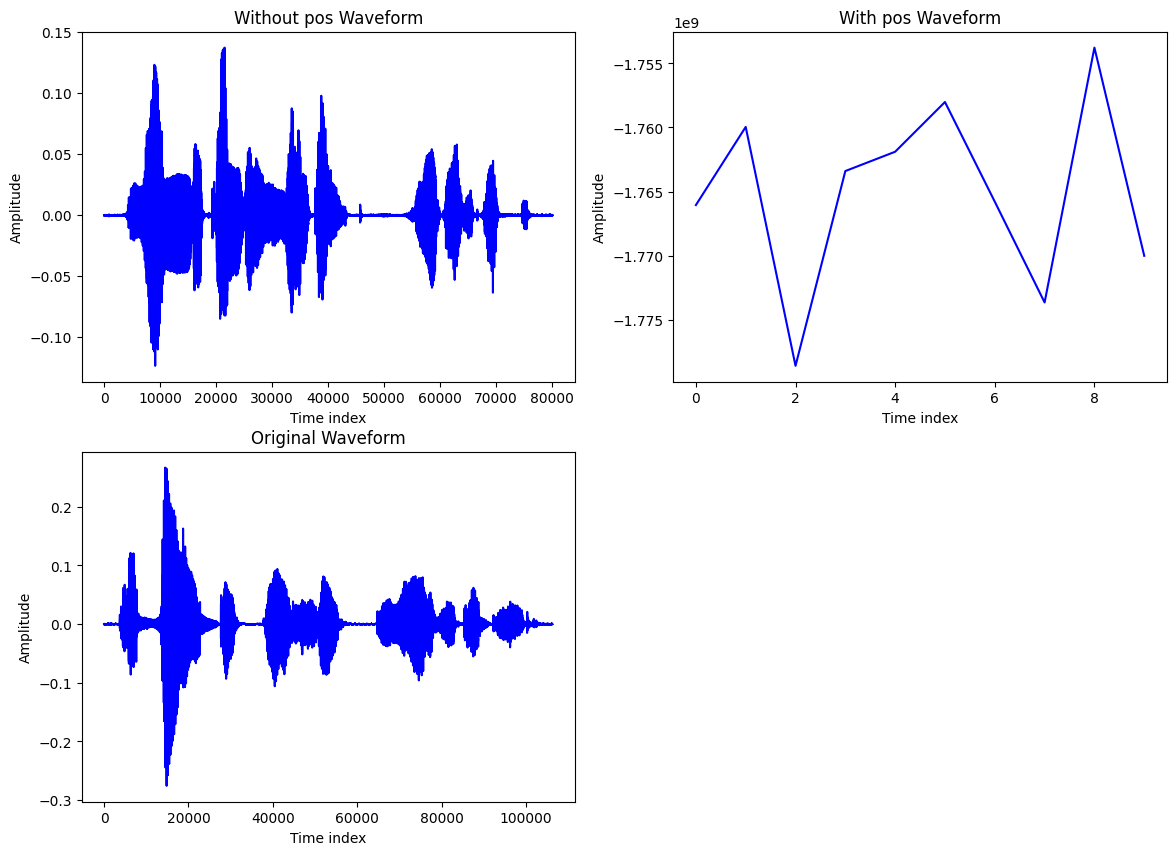

In [ ]:
import matplotlib.pyplot as plt

a=outputs_without_pos[1][0]
b=outputs[1][1]

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(a[:].detach().cpu().numpy(), color='blue')
plt.title("Without pos Waveform")
plt.xlabel("Time index")
plt.ylabel("Amplitude")

plt.subplot(2, 2, 2)
plt.plot(b[:].detach().cpu().numpy(), color='blue')
plt.title("With pos Waveform")
plt.xlabel("Time index")
plt.ylabel("Amplitude")

plt.subplot(2, 2, 3)
plt.plot(waveform1[0,:].detach().cpu().numpy(), color='blue')
plt.title("Original Waveform")
plt.xlabel("Time index")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
pip install torchinfo

Text(0, 0.5, 'Amplitude')

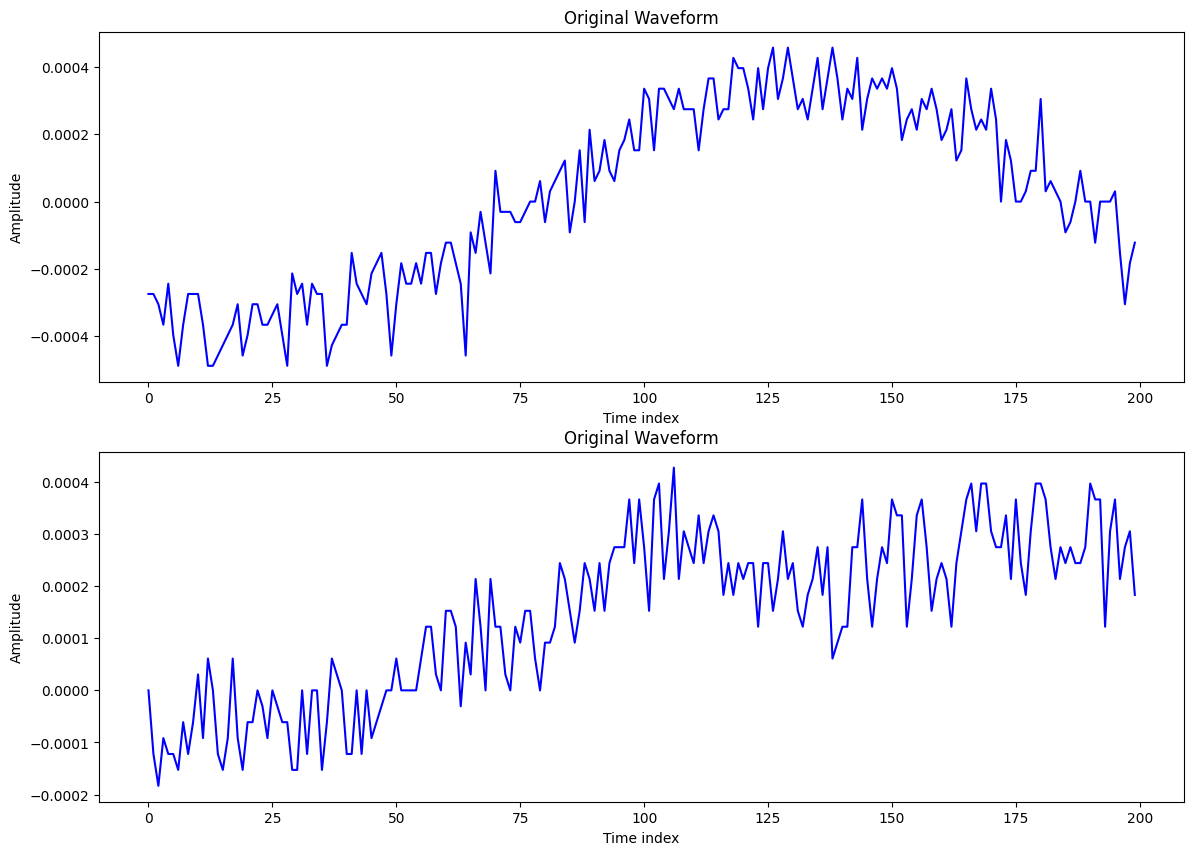

In [ ]:
import matplotlib.pyplot as plt

# Assume tensor_out is your output with shape [1, 30, 106225]
# tensor_out = out.squeeze(0)  # remove batch -> shape [30, 106225]
# waveform = waveform.squeeze(0)  # remove batch -> shape [channels, samples]
# Plot first 3 channels over first 2000 samples
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(waveform1[0, :200].detach().cpu().numpy(), color='blue')
plt.title("Original Waveform")
plt.xlabel("Time index")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(waveform2[0, :200].detach().cpu().numpy(), color='blue')
plt.title("Original Waveform")
plt.xlabel("Time index")
plt.ylabel("Amplitude")

# plt.subplot(2, 1, 2)
# for i in range(20):
#     plt.plot(tensor_out[i, :2000].detach().cpu().numpy(), label=f'Channel {i}')

# plt.title("SincConv Output (first 2000 samples)")
# plt.xlabel("Time index")
# plt.ylabel("Amplitude")
# plt.legend()
# plt.show()

torch.Size([1, 160797])
torch.Size([1, 160797])


<Figure size 1400x600 with 0 Axes>

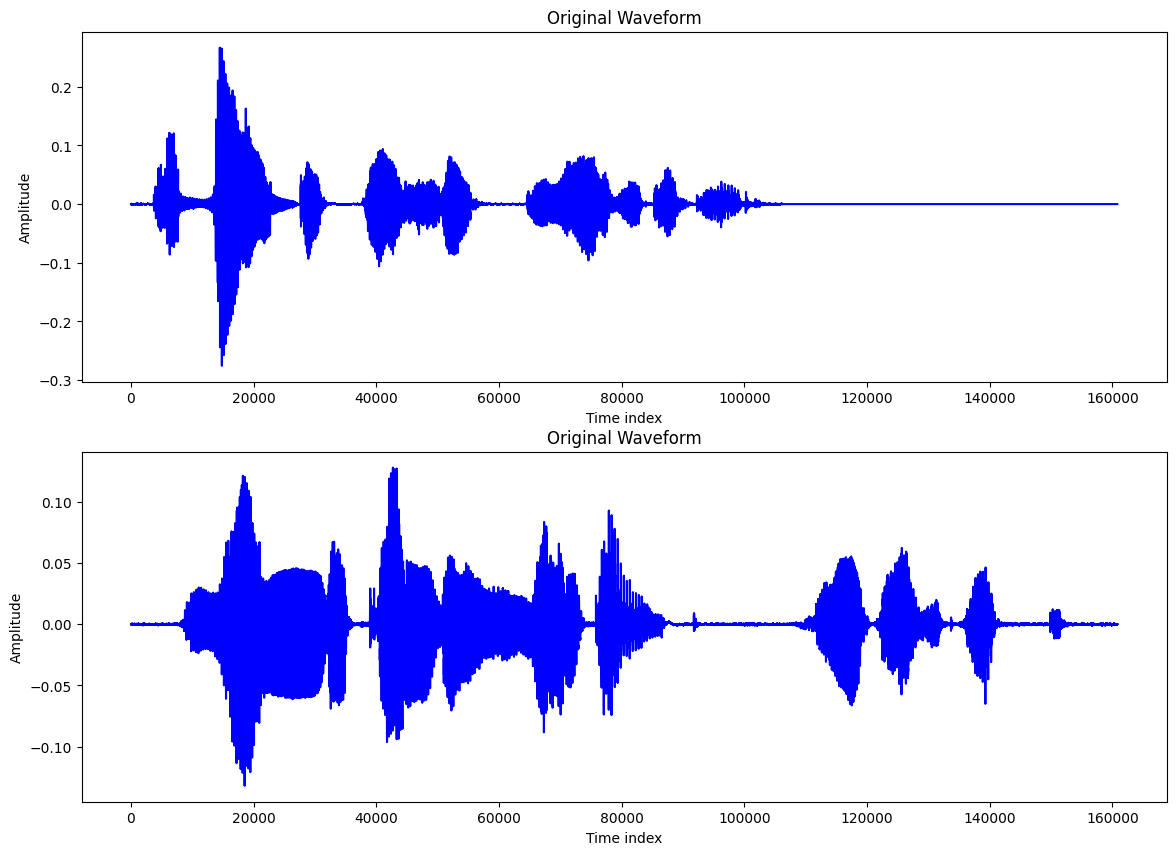

In [ ]:
plt.figure(figsize=(14, 6))
for waveforms, lengths in train_loader:
    # plt.plot(waveforms[0, ch, :2000].detach().cpu().numpy(), label=f"Channel {ch}")
    # plt.title("Original Waveform (first 2000 samples)")
    # plt.xlabel("Time index")
    # plt.ylabel("Amplitude")
    # plt.legend()
    a=waveforms[0]
    print(a.shape)
    b=waveforms[1]
    print(b.shape)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(a[0, :].detach().cpu().numpy(), color='blue')
plt.title("Original Waveform")
plt.xlabel("Time index")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(b[0, :].detach().cpu().numpy(), color='blue')
plt.title("Original Waveform")
plt.xlabel("Time index")
plt.ylabel("Amplitude")
    
plt.show()

In [ ]:
torch.arange(0,7,2)

tensor([0, 2, 4, 6])